# Lecture 6: The Forecaster's Toolbox (Part 1)

*DASCI 270 - Time Series Analysis*

*Prepared by Sebastian C. Ibañez, PhD*

*Based on [FPPY Chapter 5](https://otexts.com/fpppy/nbs/05-toolbox.html)*

`And if anyone takes away from the words of the book of this prophecy, God will take away his share in the tree of life and in the holy city, which are described in this book. -Revelation 22:19`

In this notebook, we will discuss general tools that are useful for many forecasting situations. We will also describe several benchmark forecasting methods and procedures for checking whether a forecasting method has adequately utilized the available information.

In [1]:
%%capture
!pip install statsforecast

!wget 'https://raw.githubusercontent.com/scibanez/msds2025ptb-tsa/refs/heads/main/data/aus_production_formatted.csv' -P ./data/
!wget 'https://raw.githubusercontent.com/scibanez/msds2025ptb-tsa/refs/heads/main/data/gafa_stock.csv' -P ./data/

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

from statsforecast import StatsForecast
from statsforecast.models import (
    Naive,
    SeasonalNaive,
    RandomWalkWithDrift,
    HistoricAverage,
)

plt.style.use("ggplot")
plt.rcParams.update({
    "figure.figsize": (10, 4),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
})

pd.set_option("display.precision", 3)
np.set_printoptions(suppress=True)

## Some simple forecasting methods

To properly measure the performance of a forecasting model, we first need to establish baselines. This section introduces several simple methods that will serve as benchmarks. Any forecasting method we develop must beat these benchmarks; otherwise, the new method is not worth considering.

In the notation below, $T$ refers to the length of the time series and $h$ refers to the prediction horizon.

In [3]:
df_prod = pd.read_csv("data/aus_production_formatted.csv", parse_dates=["ds"])
df_prod["ds"] = df_prod["ds"].dt.to_period('Q').dt.to_timestamp() # fix dates to QS
df_bricks = df_prod[df_prod["unique_id"] == "Bricks"]
df_bricks = df_bricks.reset_index(drop=True)
df_bricks = df_bricks.dropna() # last 20 obs
df_bricks.head()

,unique_id,ds,y
0,Bricks,1956-01-01,189.0
1,Bricks,1956-04-01,204.0
2,Bricks,1956-07-01,208.0
3,Bricks,1956-10-01,197.0
4,Bricks,1957-01-01,187.0


### Mean method

Forecasts of all future values are equal to the arithmetic average (or mean) of the historical data.

\begin{align*}
    \hat{y}_{T+h} &= \frac{y_1 + y_2 + \ldots + y_T}{T}
\end{align*}

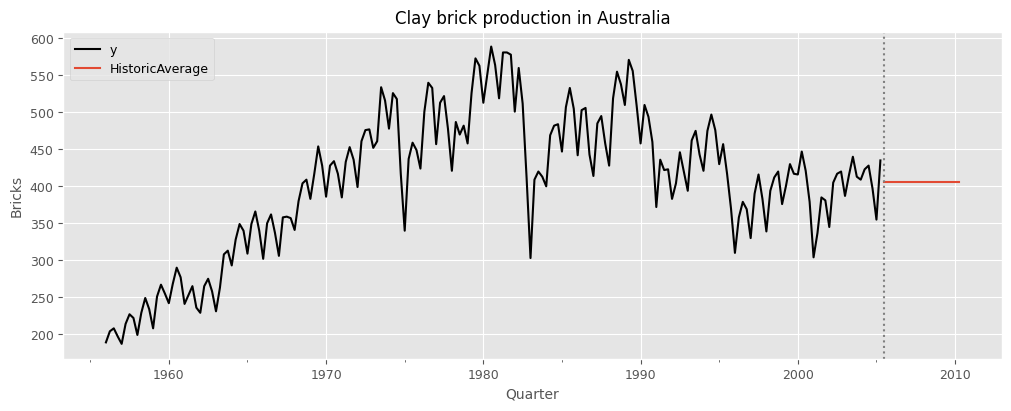

,unique_id,ds,HistoricAverage
0,Bricks,2005-07-01,405.495
1,Bricks,2005-10-01,405.495
2,Bricks,2006-01-01,405.495
3,Bricks,2006-04-01,405.495
4,Bricks,2006-07-01,405.495


In [4]:
sf = StatsForecast(models=[HistoricAverage()], freq='QS')
sf.fit(df=df_bricks)
df_f = sf.predict(h=20)

fig, ax = plt.subplots()
df_bricks.plot(ax=ax, x='ds', y='y', color='black')
df_f.plot(ax=ax, x='ds', y='HistoricAverage')
ax.set_title("Clay brick production in Australia")
ax.set_xlabel("Quarter")
ax.set_ylabel("Bricks")
plt.axvline(x=df_f['ds'].iloc[0], color='grey', linestyle='dotted') # forecast time!
plt.autoscale()
plt.show()

df_f.head()

### Naïve method

Forecasts of all future values are equal to the last observation.

\begin{align*}
    \hat{y}_{T+h} &= y_T
\end{align*}

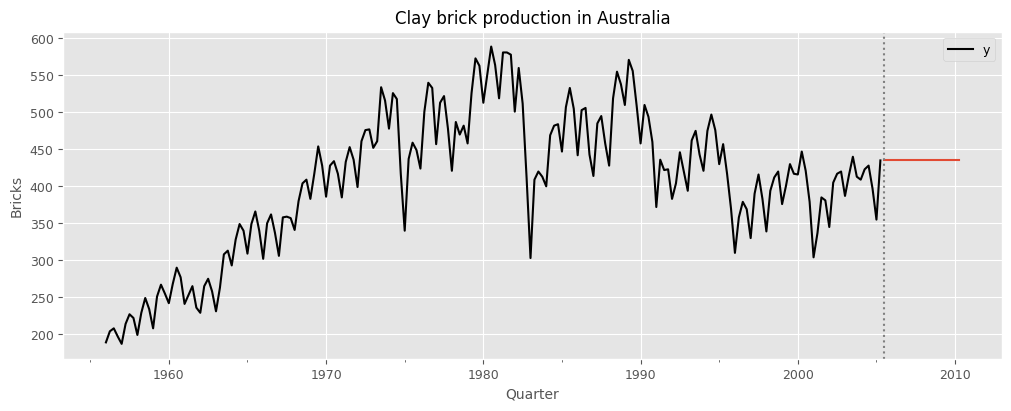

In [5]:
sf = StatsForecast(models=[Naive()], freq='QS')
sf.fit(df=df_bricks)
df_f = sf.predict(h=20)

fig, ax = plt.subplots()
df_bricks.plot(ax=ax, x='ds', y='y', color='black')
df_f.plot(ax=ax, x='ds', y='Naive', legend=False)
ax.set_title("Clay brick production in Australia")
ax.set_xlabel("Quarter")
ax.set_ylabel("Bricks")
plt.axvline(x=df_f['ds'].iloc[0], color='grey', linestyle='dotted')
plt.autoscale()
plt.show()

### Seasonal naïve method

Forecasts are equal to the last observed value from the same season of the year (e.g., the same month of the previous year).

\begin{align*}
    \hat{y}_{T+h} &= y_{T+h-m(k+1)}
\end{align*}

where $m$ is the seasonal period and $k$ is the integer part of $(h-1)/m$ (i.e. the number of complete years in the forecast period prior to time $T+h$).

For example, when forecasting a monthly time series, the forecast for all future February values is equal to the last observed February value. With weekly data, the forecast for all future Friday values is equal to the last observed Friday value, and so on.

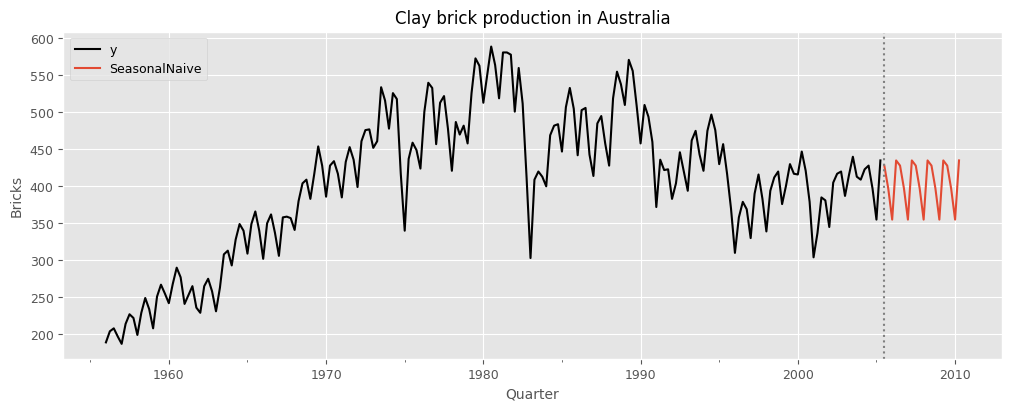

In [6]:
sf = StatsForecast(models=[SeasonalNaive(4)], freq='QS') # set m = 4
sf.fit(df=df_bricks)
df_f = sf.predict(h=20)

fig, ax = plt.subplots()
df_bricks.plot(ax=ax, x='ds', y='y', color='black')
df_f.plot(ax=ax, x='ds', y='SeasonalNaive')
ax.set_title("Clay brick production in Australia")
ax.set_xlabel("Quarter")
ax.set_ylabel("Bricks")
plt.axvline(x=df_f['ds'].iloc[0], color='grey', linestyle='dotted')
plt.autoscale()
plt.show()

### Drift method

A modification of the Naive method is to add a trend component to the forecasts, allowing them to increase or decrease over time. The drift term is the average change observed in the historical data.

\begin{align*}
    \hat{y}_{T+h} &= y_T  + h\left( \frac{y_T - y_1}{T-1} \right)
\end{align*}

This is equivalent to drawing a line between the first and last observations and extrapolating it into the future.

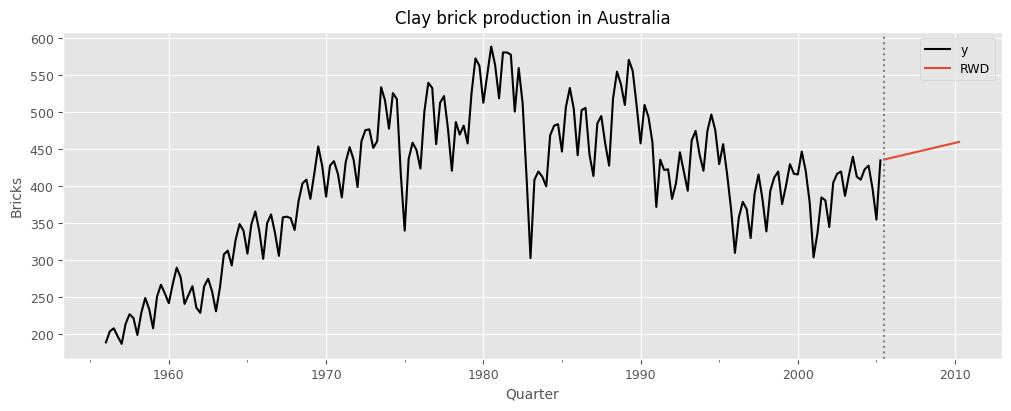

In [7]:
sf = StatsForecast(models=[RandomWalkWithDrift()], freq='QS') # don't mind the "random walk" part
sf.fit(df=df_bricks)
df_f = sf.predict(h=20)

fig, ax = plt.subplots()
df_bricks.plot(ax=ax, x='ds', y='y', color='black')
df_f.plot(ax=ax, x='ds', y='RWD')
ax.set_title("Clay brick production in Australia")
ax.set_xlabel("Quarter")
ax.set_ylabel("Bricks")
plt.axvline(x=df_f['ds'].iloc[0], color='grey', linestyle='dotted')
plt.autoscale()
plt.show()

### Example: Australian quarterly beer production

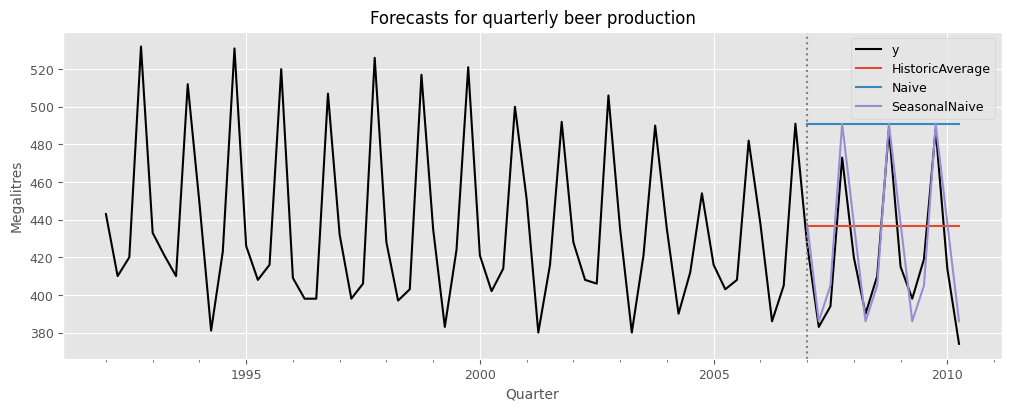

In [8]:
df_beer = df_prod[df_prod["unique_id"] == "Beer"]
df_beer = df_beer[df_beer["ds"] >= "1992-01-01"]
df_beer = df_beer.reset_index(drop=True)
df_train = df_beer.iloc[:-14]
df_test = df_beer.iloc[-14:]

sf = StatsForecast(
    models=[HistoricAverage(), Naive(), SeasonalNaive(4)],
    freq="QS"
)
sf.fit(df_train)
df_f = sf.predict(h=14)

fig, ax = plt.subplots()
df_beer.plot(ax=ax, x='ds', y='y', color='black')
df_f.plot(ax=ax, x='ds')
ax.set_title("Forecasts for quarterly beer production")
ax.set_xlabel("Quarter")
ax.set_ylabel("Megalitres")
plt.axvline(x=df_f['ds'].iloc[0], color='grey', linestyle='dotted')
plt.autoscale()
plt.show()

### Example: Google's daily closing stock price

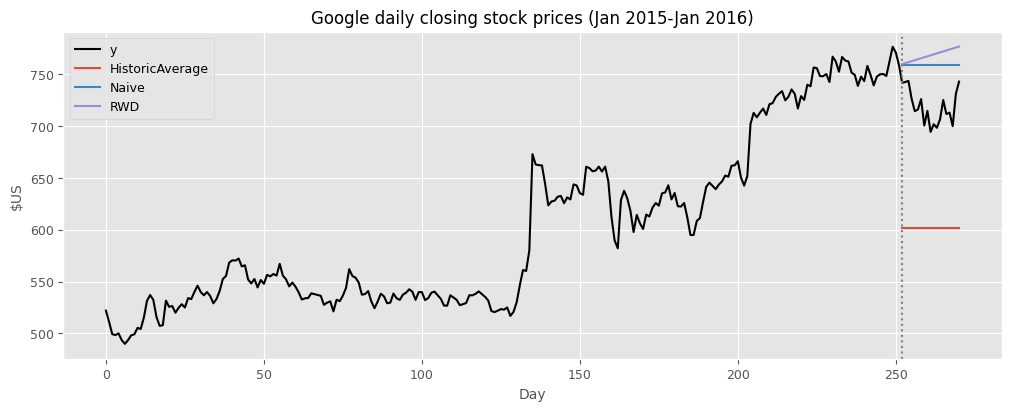

In [9]:
df_gafa = pd.read_csv("data/gafa_stock.csv", parse_dates=["ds"])
df_goog = df_gafa.query("unique_id == 'GOOG_Close' and '2015-01-01' <= ds <= '2016-01-31'")
df_goog = df_goog.reset_index(drop=True)

df_train = df_goog.query("ds.dt.year == 2015").copy()
df_test = df_goog.query("ds.dt.year == 2016").copy()

# REMOVE dates: ignore weekends, holidays
df_train["ds"] = np.arange(len(df_train))
df_test["ds"] = np.arange(len(df_test))

sf = StatsForecast(models=[HistoricAverage(), Naive(), RandomWalkWithDrift()], freq=1)
sf.fit(df_train)
df_f = sf.predict(h=len(df_test))

fig, ax = plt.subplots()
df_goog.plot(ax=ax, y='y', color='black')
df_f.plot(ax=ax, x='ds')
ax.set_title("Google daily closing stock prices (Jan 2015-Jan 2016)")
ax.set_xlabel("Day")
ax.set_ylabel("$US")
plt.axvline(x=df_f['ds'].iloc[0], color='grey', linestyle='dotted')
plt.autoscale()
plt.show()

## Fitted values

**Fitted values**, denoted as $\hat{y}_t$, are predictions made on the training data. They are not "true" forecasts because the parameters are estimated using all available observations, meaning a prediction can be conditioned on future values.

The exceptions are the naive and seasonal naive forecasts, which do not involve parameters or make use of future observations.

Note that fitted values are always one-step-ahead forecasts.

In [10]:
df_train = df_beer[:-14]
df_test = df_beer[-14:]

sf = StatsForecast(models=[HistoricAverage()], freq="QS")
df_f = sf.forecast(h=14, df=df_train, fitted=True) # NOTE: forecast() is like sklearn fit_predict(), can also be used to get fitted values
df_f.head()

,unique_id,ds,HistoricAverage
0,Beer,2007-01-01,436.45
1,Beer,2007-04-01,436.45
2,Beer,2007-07-01,436.45
3,Beer,2007-10-01,436.45
4,Beer,2008-01-01,436.45


In [11]:
df_fitted = sf.forecast_fitted_values() # get fitted values
df_fitted = df_fitted.rename({"HistoricAverage": "fitted"}, axis=1)
df_fitted.head()

,unique_id,ds,y,fitted
0,Beer,1992-01-01,443.0,436.45
1,Beer,1992-04-01,410.0,436.45
2,Beer,1992-07-01,420.0,436.45
3,Beer,1992-10-01,532.0,436.45
4,Beer,1993-01-01,433.0,436.45


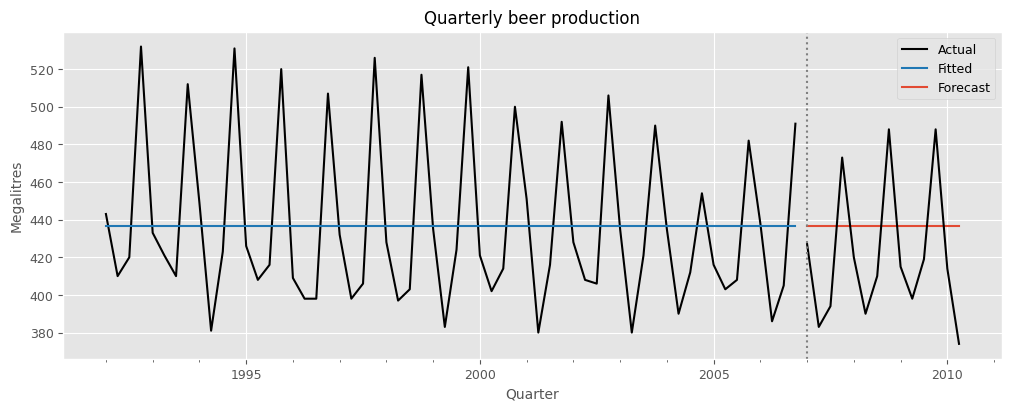

In [12]:
fig, ax = plt.subplots()
df_fitted.plot(ax=ax, x='ds', y='y', color='black', legend=False)         # train data
df_fitted.plot(ax=ax, x='ds', y='fitted', color='tab:blue', legend=False) # fitted values
df_f.plot(ax=ax, x='ds', y='HistoricAverage', legend=False)               # forecast
df_test.plot(ax=ax, x='ds', y='y', color='black', legend=False)           # test data
ax.set_title("Quarterly beer production")
ax.set_xlabel("Quarter")
ax.set_ylabel("Megalitres")
plt.axvline(x=df_f['ds'].iloc[0], color='grey', linestyle='dotted')
plt.legend(['Actual', 'Fitted', 'Forecast'])
plt.autoscale()
plt.show()

## Errors and residuals

*Note: The discussion below diverges slightly from the textbook.*

The **errors** of a model are the difference between the actual data $y_i$ and the model's prediction $\hat{y}_i$,

\begin{align*}
  \varepsilon_i &= y_i - \hat{y}_i
\end{align*}

In the context of time series forecasting, we can further specify two kinds of "errors": forecast errors and residuals.

### Forecast errors

**Forecast errors** are errors we observe when a model predicts on out-of-sample or test data:

\begin{align*}
  e_{T+h} &= y_{T+h} - \hat{y}_{T+h|T}
\end{align*}

where the training data is given by $\{y_1, y_2, \ldots, y_T \} $ and the test data is given by $\{y_{T+1}, y_{T+2}, y_{T+3}, \ldots \} $.

These errors are also sometimes called **out-of-sample errors**.

We will revisit this topic in more detail when we reach the section on performance evaluation and forecast accuracy.

In [13]:
df_errors = pd.merge(df_test, df_f, on=['ds', 'unique_id'])
df_errors['error'] = df_errors['y'] - df_errors['HistoricAverage'] # forecast errors!
df_errors.head()

,unique_id,ds,y,HistoricAverage,error
0,Beer,2007-01-01,427.0,436.45,-9.45
1,Beer,2007-04-01,383.0,436.45,-53.45
2,Beer,2007-07-01,394.0,436.45,-42.45
3,Beer,2007-10-01,473.0,436.45,36.55
4,Beer,2008-01-01,420.0,436.45,-16.45


### Residuals

The **residuals** of a time series model are the errors we observe when predicting on in-sample or training data:

\begin{align*}
    e_t &= y_t - \hat{y}_t
\end{align*}

In other words, they are the difference between actual training data and the fitted values.

These are sometimes referred to as "in-sample errors".

In [14]:
df_fitted["resid"] = df_fitted["y"] - df_fitted["fitted"]
df_fitted.head()

,unique_id,ds,y,fitted,resid
0,Beer,1992-01-01,443.0,436.45,6.55
1,Beer,1992-04-01,410.0,436.45,-26.45
2,Beer,1992-07-01,420.0,436.45,-16.45
3,Beer,1992-10-01,532.0,436.45,95.55
4,Beer,1993-01-01,433.0,436.45,-3.45


Lastly, if a transformation was performed on the data (e.g. log or Box-Cox), then residuals on the transformed scale are sometimes called **innovation residuals**.

## Residual diagnostics


Examining the residuals of a model can be used to check whether the model has adequately captured the information in the data. In other words, analyzing residuals can help us measure a model's goodness-of-fit.  

A good forecasting method will yield residuals with the following properties:

1. **Residuals are uncorrelated**. Otherwise, there is information in the residuals that can be exploited.
2. **Residuals have zero mean**. Otherwise, the forecasts are biased.

Any forecasting method that does not satisfy these properties can be improved. However, this does not mean that forecasting methods that do satisfy these properties cannot be improved.

Additionally, it is useful (but not necessary) for residuals to also have the following properties:

3. **Residuals have constant variance**.
4. **Residuals are normally distributed**.

These properties make the calculation of prediction intervals easier.

### Example: Forecasting Google daily closing stock prices

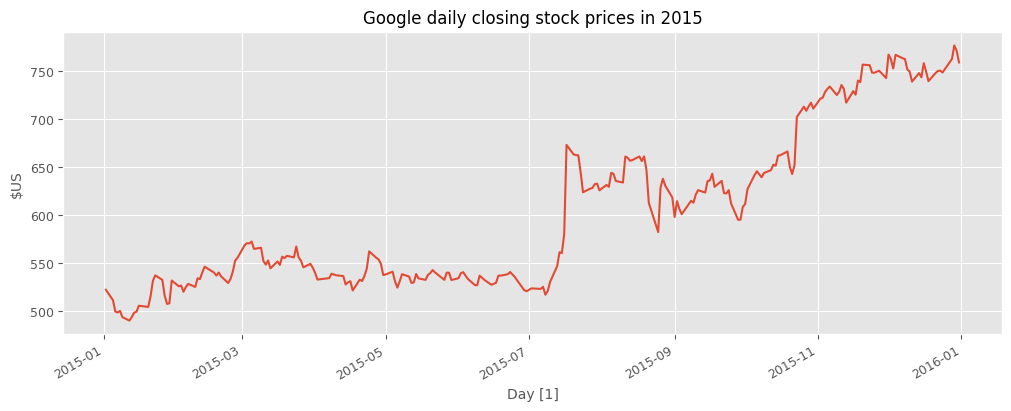

In [15]:
df_train = df_goog.query("ds.dt.year == 2015").copy()

fig, ax = plt.subplots()
df_train.plot(ax=ax, x='ds', y='y', legend=False)
ax.set_title("Google daily closing stock prices in 2015")
ax.set_xlabel("Day [1]")
ax.set_ylabel("$US")
plt.autoscale()
plt.show()

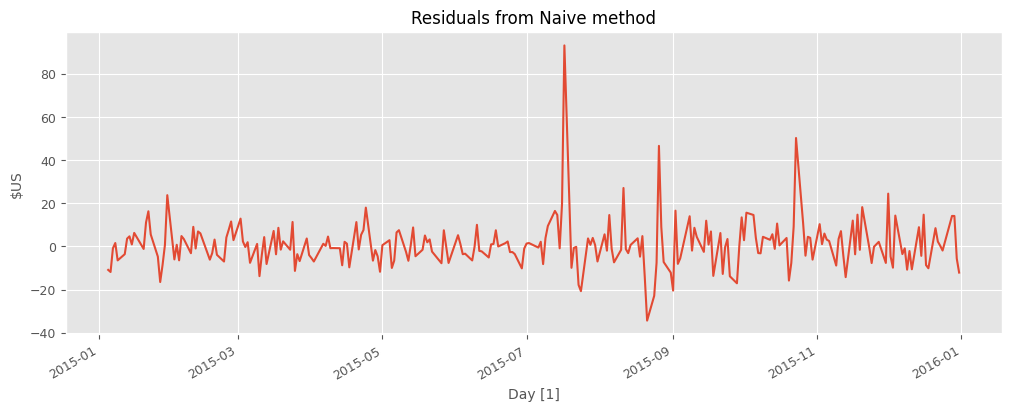

In [16]:
df_train["resid"] = df_train["y"].diff().values # easy trick to get Naive forecasts/residuals

fig, ax = plt.subplots()
df_train.plot(ax=ax, x='ds', y='resid', legend=False)
ax.set_title("Residuals from Naive method")
ax.set_xlabel("Day [1]")
ax.set_ylabel("$US")
plt.autoscale()
plt.show()

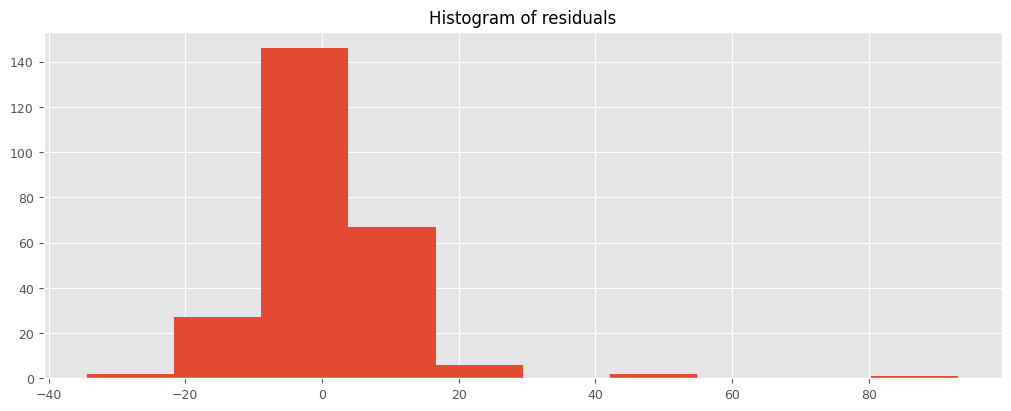

In [17]:
ax = df_train["resid"].hist()
ax.set_title("Histogram of residuals")
plt.show()

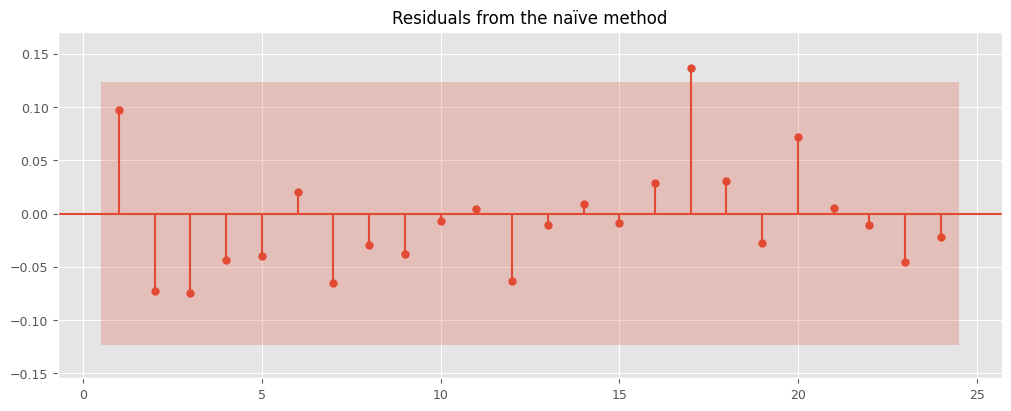

In [18]:
fig = plot_acf(df_train["resid"][1:], zero=False, auto_ylims=True, bartlett_confint=False, title="Residuals from the naïve method")

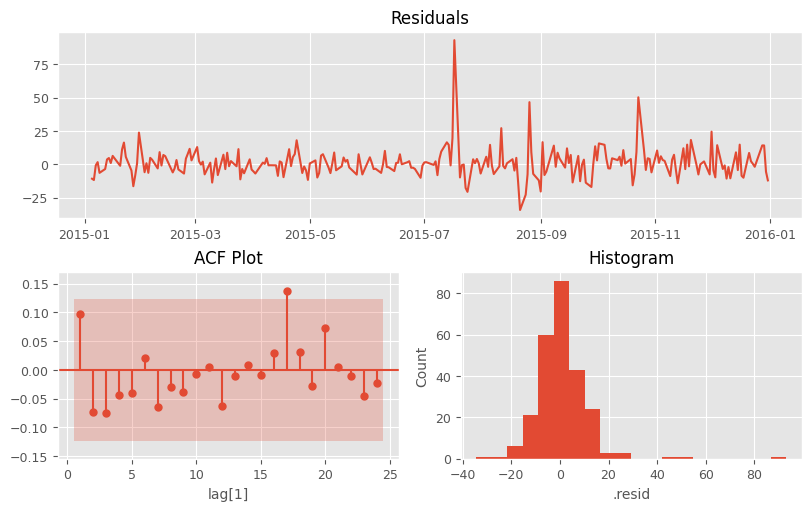

In [19]:
fig = plt.figure(figsize=(8, 5))

ax1 = fig.add_subplot(2, 2, (1, 2))
ax1.plot(df_train['ds'], df_train["resid"])
ax1.set_title("Residuals")

ax2 = fig.add_subplot(2, 2, 3)
plot_acf(df_train["resid"].dropna(), ax=ax2, zero=False,
  bartlett_confint=False, auto_ylims=True)
ax2.set_title("ACF Plot")
ax2.set_xlabel('lag[1]')

ax3 = fig.add_subplot(2, 2, 4)
ax3.hist(df_train["resid"], bins=20)
ax3.set_title("Histogram")
ax3.set_xlabel(".resid")
ax3.set_ylabel("Count")

plt.show()

Some notes on the plots above:

- Residual time plot shows that the variation of the residuals stays much the same across the historical data, apart from the one outlier
- Mean of residuals is close to zero
- Right tail on histogram seems too long for a normal distribution
- ACF plot shows no significant correlation in the residual series
- In general, the plots suggest that the naive method produces forecasts that appear to account for all available information
- Prediction intervals that are computed assuming a normal distribution may be inaccurate

### Portmanteau tests for autocorrelation

Instead of visually inspecting ACF plots, we can perform formal hypothesis tests on the residuals to check for autocorrelation.

The two most common tests are the **Box-Pierce test** and the **Ljung-Box test**. See [FPP3](https://otexts.com/fpp3/diagnostics.html) for more details.

For these tests, the hypotheses are:

- $H_0$: The data are independently distributed.

- $H_1$: The data are not independently distributed; they exhibit serial correlation.

<b>RECALL:</b> If $p < \alpha$, then we reject the null hypothesis.

In [20]:
resid_test = acorr_ljungbox(df_train["resid"].dropna(), boxpierce=True)
resid_test

,lb_stat,lb_pvalue,bp_stat,bp_pvalue
1,2.417,0.120,2.389,0.122
2,3.761,0.153,3.711,0.156
3,5.193,0.158,5.115,0.164
4,5.675,0.225,5.585,0.232
5,6.084,0.298,5.983,0.308
6,6.195,0.402,6.090,0.413
7,7.303,0.398,7.159,0.413
8,7.525,0.481,7.372,0.497
9,7.902,0.544,7.733,0.561
10,7.914,0.637,7.745,0.654




For both Box-Pierce and Ljung-Box statistics, the results are not significant (i.e. p-values are relatively large).

Thus, we can conclude that the residuals are NOT distinguishable from a white noise series (i.e. there is no serial correlation).